In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Service Logic (M/M/s Core Formulas)

In [3]:
def calculateP0(lambd, mu, s):
    sumTerm = sum([(lambd / mu) ** n / math.factorial(n) for n in range(s)])
    lastTerm = ((lambd / mu) ** s) / (math.factorial(s) * (1 - (lambd / (s * mu))))
    return 1 / (sumTerm + lastTerm)

def calculateLq(lambd, mu, s, p0, rho):
    numerator = p0 * ((lambd / mu) ** s) * rho
    denominator = math.factorial(s) * ((1 - rho) ** 2)
    return numerator / denominator

def calculateQueueMetrics(row, sOverride=None):
    lambd = row['lambda_arrival']
    mu = row['mu_service']
    s = sOverride if sOverride is not None else row['cs_count']
    
    rho = lambd / (s * mu)
    if rho >= 1:
        return pd.Series([rho, 1.0, np.inf, np.inf, np.inf, np.inf])
        
    p0 = calculateP0(lambd, mu, s)
    lq = calculateLq(lambd, mu, s, p0, rho)
    ls = lq + (lambd / mu)
    wq = (lq / lambd) * 60 
    ws = (ls / lambd) * 60 
    
    return pd.Series([rho, p0, lq, ls, wq, ws])

# Data Loading, Execution, and Validation

In [7]:
dfAntrean = pd.read_csv('data_antrean.csv')
dfValidasiJurnal = pd.read_csv('data_validasi.csv')

metricsCols = ['rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']

dfRiyals = dfAntrean.copy()
dfRiyals[metricsCols] = dfRiyals.apply(calculateQueueMetrics, axis=1)

dfSkenarioBaru = dfAntrean.copy()
dfSkenarioBaru[metricsCols] = dfSkenarioBaru.apply(lambda row: calculateQueueMetrics(row, sOverride=2), axis=1)

dfValidationComparison = pd.DataFrame({
    'blok_jam': dfRiyals['blok_jam'],
    'rho_python': dfRiyals['rho'],
    'rho_jurnal': dfValidasiJurnal['rho_jurnal'],
    'wq_python_minutes': dfRiyals['wq_minutes'],
    'wq_jurnal_minutes': dfValidasiJurnal['wq_jurnal'],
    'ws_python_minutes': dfRiyals['ws_minutes'],
    'ws_jurnal_minutes': dfValidasiJurnal['ws_jurnal']
})

dfValidationComparison['error_wq'] = np.abs(dfValidationComparison['wq_python_minutes'] - dfValidationComparison['wq_jurnal_minutes'])

pd.options.display.float_format = '{:.3f}'.format
print(dfValidationComparison[['blok_jam', 'wq_python_minutes', 'wq_jurnal_minutes', 'error_wq']])
print("\n" + "="*50 + "\n")
print("=== KONDISI 1 CS ===")
print(dfRiyals[['blok_jam', 'rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']])
print("\n" + "="*50 + "\n")
print("=== SKENARIO 2 CS ===")
print(dfSkenarioBaru[['blok_jam', 'rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']])

  blok_jam  wq_python_minutes  wq_jurnal_minutes  error_wq
0        A              6.429              6.430     0.001
1        B             12.500             12.500     0.000
2        C             12.500             12.500     0.000
3        D              4.500              4.500     0.000
4        E              5.000              5.000     0.000
5        F              3.429              3.430     0.001


=== KONDISI 1 CS ===
  blok_jam   rho    p0    lq    ls  wq_minutes  ws_minutes
0        A 0.429 0.571 0.321 0.750       6.429      15.000
1        B 0.625 0.375 1.042 1.667      12.500      20.000
2        C 0.625 0.375 1.042 1.667      12.500      20.000
3        D 0.375 0.625 0.225 0.600       4.500      12.000
4        E 0.333 0.667 0.167 0.500       5.000      15.000
5        F 0.286 0.714 0.114 0.400       3.429      12.000


=== SKENARIO 2 CS ===
  blok_jam   rho    p0    lq    ls  wq_minutes  ws_minutes
0        A 0.214 0.647 0.021 0.449       0.413       8.984
1        

# Visualisasi

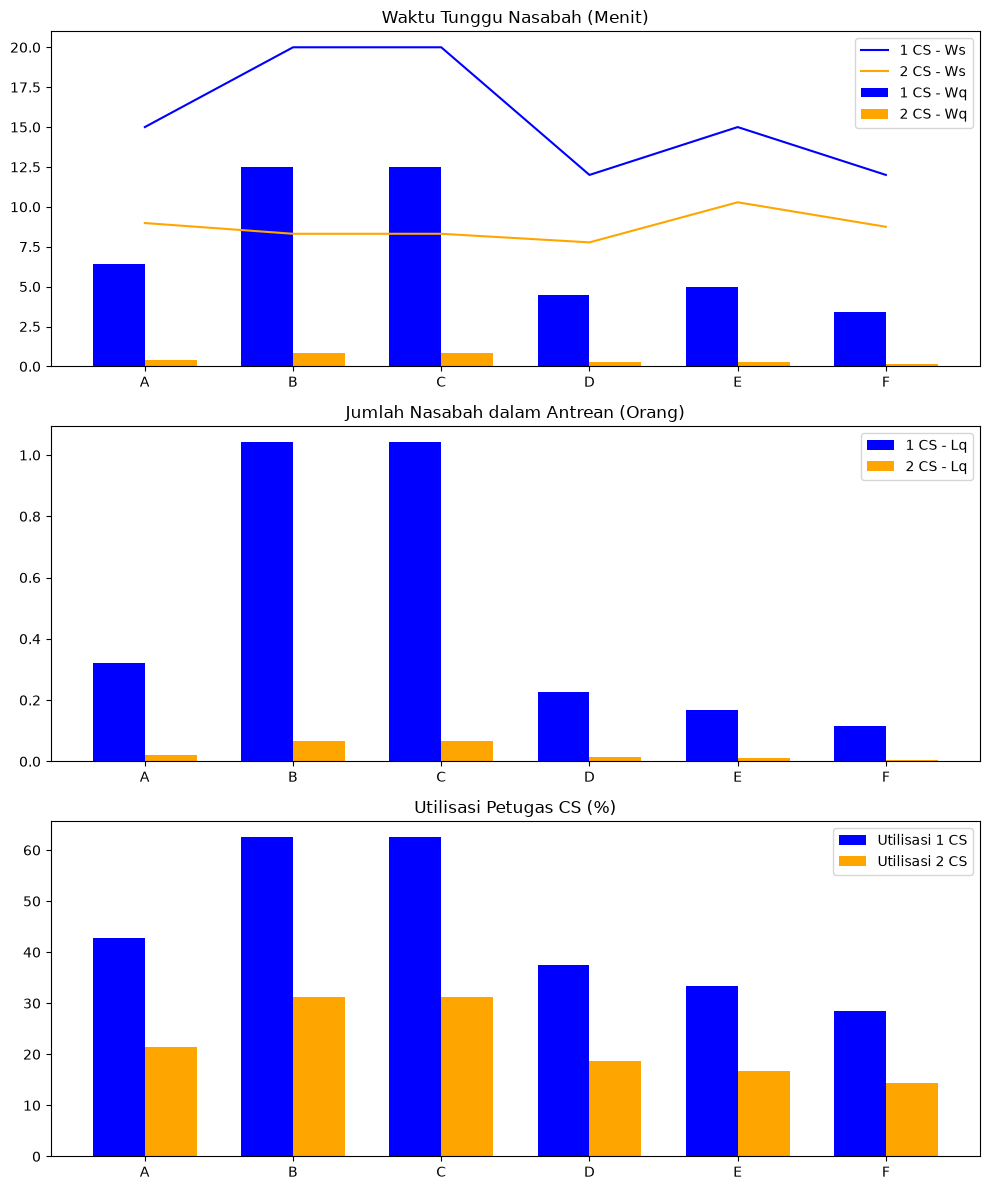

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
x = np.arange(len(dfAntrean['blok_jam']))
width = 0.35

# 1. Grafik Perbandingan Waktu Tunggu
axes[0].bar(x - width/2, dfRiyals['wq_minutes'], width, label='1 CS - Wq', color='blue')
axes[0].bar(x + width/2, dfSkenarioBaru['wq_minutes'], width, label='2 CS - Wq', color='orange')
axes[0].plot(x, dfRiyals['ws_minutes'], label='1 CS - Ws', color='blue')
axes[0].plot(x, dfSkenarioBaru['ws_minutes'], label='2 CS - Ws', color='orange')
axes[0].set_title('Waktu Tunggu Nasabah (Menit)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dfAntrean['blok_jam'])
axes[0].legend()

# 2. Grafik Perbandingan Jumlah Nasabah
axes[1].bar(x - width/2, dfRiyals['lq'], width, label='1 CS - Lq', color='blue')
axes[1].bar(x + width/2, dfSkenarioBaru['lq'], width, label='2 CS - Lq', color='orange')
axes[1].set_title('Jumlah Nasabah dalam Antrean (Orang)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dfAntrean['blok_jam'])
axes[1].legend()

# 3. Grafik Perbandingan Utilisasi Server
axes[2].bar(x - width/2, dfRiyals['rho'] * 100, width, label='Utilisasi 1 CS', color='blue')
axes[2].bar(x + width/2, dfSkenarioBaru['rho'] * 100, width, label='Utilisasi 2 CS', color='orange')
axes[2].set_title('Utilisasi Petugas CS (%)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(dfAntrean['blok_jam'])
axes[2].legend()

plt.tight_layout()
plt.show()